In [11]:
from langchain_ollama import OllamaLLM
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="minimax-m3:cloud",
    temperature=0
)

In [12]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict
from pydantic import BaseModel,Field

#### 1.Prompt Chaining -Job Application Assistant

In [13]:
class ChainState(TypedDict):
    job_description:str
    resume_summary:str
    cover_letter:str

##### resume summary agent

In [14]:
def generate_resume_summary(state: ChainState)->ChainState:
    prompt=f"""
    You're a resume assistant. read the following job description and summarize
    the key qualifications and experience the ideal candidate should have,phrased as
    if from the perspective of a strong applicant's resume summary.
    
    Job Description:
    {state['job_description']}
    
    """
    response=llm.invoke(prompt)
    return {**state,"resume_summary":response.content}

##### generate cover letter agent

In [15]:
def generate_cover_letter(state:ChainState)->ChainState:
    prompt=f"""
    You're a cover letter writing assistant. Using the resume summary below,
    write a professional and personalized cover letter for the following job.
    
    Resume Summary:
    {state['resume_summary']}
    
    Job Description:
    {state['job_description']}
    """
    
    response=llm.invoke(prompt)
    
    return {**state,"cover_letter":response.content}

##### initializing the langgraph workflow

In [16]:
workflow=StateGraph(ChainState)
workflow

In [17]:
workflow.add_node('generate_resume_summary',generate_resume_summary)
workflow.add_node('generate_cover_letter',generate_cover_letter)
workflow.set_entry_point('generate_resume_summary')
workflow.add_edge('generate_resume_summary','generate_cover_letter')
workflow.set_finish_point('generate_cover_letter')

In [18]:
app=workflow.compile()

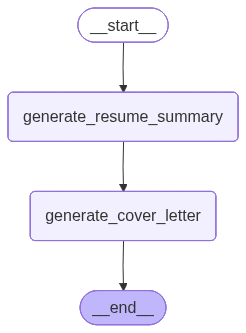

In [29]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
input_state = {
        "job_description": "We are looking for a data scientist with experience in machine learning, NLP, and Python. Prior work with large datasets and experience deploying models into production is required."
}

result = app.invoke(input_state)

In [22]:
result['resume_summary']

'**Resume Summary:**\n\nResults-driven Data Scientist with extensive experience in machine learning, natural language processing (NLP), and Python development. Proven ability to work with large-scale datasets and build end-to-end data pipelines, with a strong track record of successfully deploying models into production environments. Skilled at translating complex data into actionable insights and scalable solutions that deliver measurable business impact.'

In [23]:
result['cover_letter']

"# Cover Letter\n\n**[Your Name]**\n[Your Address]\n[City, State, ZIP]\n[Your Email] | [Your Phone Number] | [LinkedIn Profile]\n\n[Date]\n\n**Hiring Manager**\n[Company Name]\n[Company Address]\n[City, State, ZIP]\n\nDear Hiring Manager,\n\nI am writing to express my interest in the Data Scientist position at [Company Name]. With extensive experience in machine learning, natural language processing, and Python development, I am confident in my ability to contribute meaningfully to your data science team and help drive data-informed decision-making across the organization.\n\nThroughout my career, I have developed deep expertise in building and deploying machine learning models that solve real-world business problems. My hands-on experience with NLP has enabled me to extract valuable insights from unstructured text data, while my proficiency in Python allows me to design clean, efficient, and scalable solutions. I have consistently leveraged these skills to tackle complex challenges an